# CS 4412 – Data Mining
## M3: Complete Implementation
### Pattern Discovery in U.S. Transportation Systems

This notebook implements a complete data mining pipeline using the Monthly Transportation Statistics dataset.

The goal is to identify meaningful patterns in transportation activity and safety using clustering, dimensionality reduction, and classification techniques.

## Dataset Clarification

The project initially proposed an automobile sales dataset in M1. However, the dataset was changed in M2 to the Monthly Transportation Statistics dataset to better support clustering and multi-modal transportation analysis.

All analysis in this notebook is based on the transportation dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Data Loading

In [2]:
df = pd.read_csv("../data/Monthly_Transportation_Statistics_20260308.csv")
df.head()

,Index,Date,Air Safety - General Aviation Fatalities,Highway Fatalities Per 100 Million Vehicle Miles Traveled,Highway Fatalities,U.S. Airline Traffic - Total - Seasonally Adjusted,U.S. Airline Traffic - International - Seasonally Adjusted,U.S. Airline Traffic - Domestic - Seasonally Adjusted,Transit Ridership - Other Transit Modes - Adjusted,Transit Ridership - Fixed Route Bus - Adjusted,...,Heavy truck sales SAAR (millions),U.S. Airline Traffic - Total - Non Seasonally Adjusted,Light truck sales SAAR (millions),U.S. Airline Traffic - International - Non Seasonally Adjusted,Auto sales SAAR (millions),U.S. Airline Traffic - Domestic - Non Seasonally Adjusted,Transborder - Total North American Freight,Transborder - U.S. - Mexico Freight,U.S. marketing air carriers on-time performance (percent),Transborder - U.S. - Canada Freight
0,0,1947 Jan 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1947 Feb 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1947 Mar 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1947 Apr 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1947 May 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing

The dataset is cleaned to remove non-informative features and handle missing values properly.

Key steps:
- Remove Index column
- Drop sparse columns
- Handle missing and infinite values

In [3]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df = numeric_df.drop(columns=['Index'], errors='ignore')

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

threshold = 0.5
numeric_df = numeric_df.loc[:, numeric_df.notna().mean() > threshold]

numeric_df = numeric_df.fillna(numeric_df.mean())

print(numeric_df.shape)

(951, 4)


## Feature Scaling
Standardization ensures all features contribute equally to clustering.

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

## Determining Optimal Number of Clusters (Elbow Method)

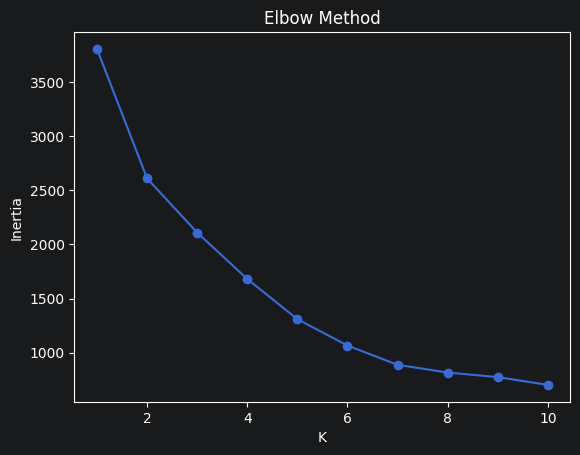

In [5]:

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

## Silhouette Score Evaluation

In [6]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.483
k=3, silhouette=0.396
k=4, silhouette=0.423
k=5, silhouette=0.473
k=6, silhouette=0.489
k=7, silhouette=0.510
k=8, silhouette=0.495
k=9, silhouette=0.495


## Final Clustering Model (k = 3)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

numeric_df["Cluster"] = clusters

## PCA Visualization

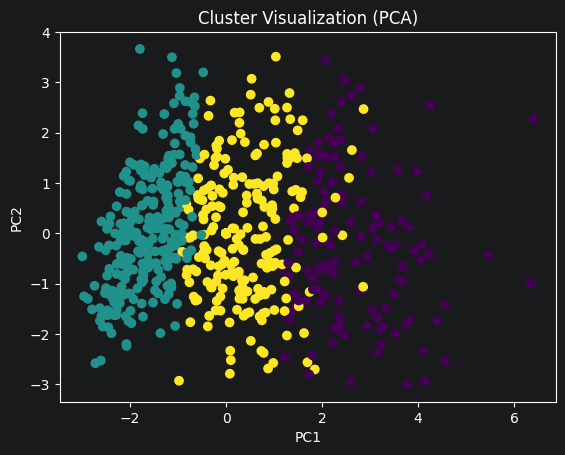

In [8]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df["Cluster"] = clusters

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Cluster"])
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("pca_plot.png")
plt.show()

## Cluster Analysis

In [9]:
numeric_df.groupby("Cluster").mean()

,Air Safety - General Aviation Fatalities,Rail Fatalities,Rail Fatalities at Highway-Rail Crossings,Trespasser Fatalities Not at Highwaya-Rail Crossings
Cluster,,,,
0,77.914136,122.541985,73.564885,38.534351
1,33.962825,66.739649,22.576561,40.933779
2,69.370073,87.048452,41.249292,40.302179


## Cluster Interpretation

- **Cluster 0:** High activity and high fatality system
- **Cluster 1:** Low activity and low fatality system
- **Cluster 2:** Moderate risk with high freight activity

These clusters demonstrate a relationship between transportation intensity and safety outcomes.

## Classification for Interpretation (Decision Tree)

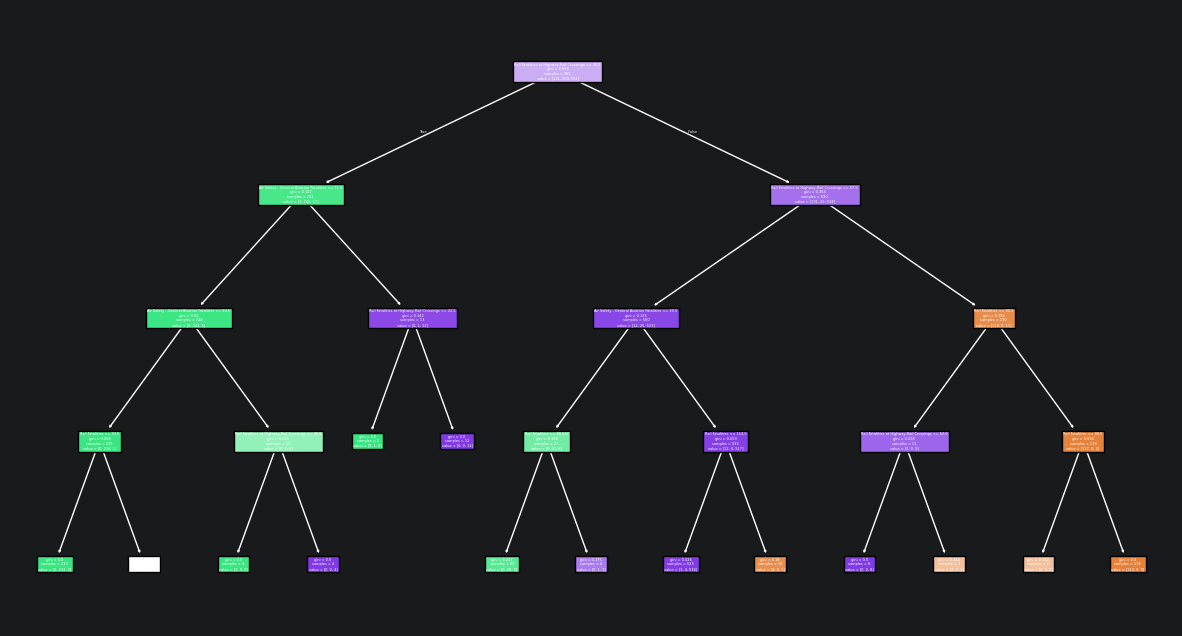

In [10]:
X = numeric_df.drop(columns=["Cluster"])
y = numeric_df["Cluster"]

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)

plt.figure(figsize=(15, 8))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

## Final Insights

- Three meaningful transportation system patterns were identified
- Freight and fatality metrics are key distinguishing features
- Higher activity systems tend to have higher safety risks

This analysis demonstrates a complete data mining pipeline with interpretable results.